In [15]:
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os
import re
from pathlib import Path
from collections import defaultdict


logs = Path("/home/yarl/Desktop/git/Urban/src/res/logs/DQN/details")

In [2]:
def parse(path):
    data = {}

    with open(path, 'r') as f:
        text = f.read()

    match = re.search(r"env_(\d+)_ep(\d+)", path.name)
    data['env'] = int(match.group(1))
    data['episode'] = int(match.group(2))

    perf = re.search(
        r"Duration:\s*([\d.]+)s.*?"
        r"TraCI-Duration:\s*([\d.]+)s.*?"
        r"Real time factor:\s*([\d.]+).*?"
        r"UPS:\s*([\d.]+)",
        text,
        re.S
    )
    if perf:
        data['duration'] = float(perf.group(1))
        data['traci_duration'] = float(perf.group(2))
        data['real_time_factor'] = float(perf.group(3))
        data['ups'] = float(perf.group(4))

    veh = re.search(
        r"Inserted:\s*(\d+)\s*\(Loaded:\s*(\d+)\).*?"
        r"Running:\s*(\d+).*?"
        r"Waiting:\s*(\d+).*?"
        r"Teleports:\s*(\d+)\s*"
        r"\(Collisions:\s*(\d+),\s*Jam:\s*(\d+),\s*Yield:\s*(\d+),\s*Wrong Lane:\s*(\d+)\).*?"
        r"Emergency Stops:\s*(\d+).*?"
        r"Emergency Braking:\s*(\d+)",
        text,
        re.S
    )
    if veh:
        (
            data["vehicles_inserted"],
            data["vehicles_loaded"],
            data["vehicles_running"],
            data["vehicles_waiting"],
            data["teleports_total"],
            data["teleports_collisions"],
            data["teleports_jam"],
            data["teleports_yield"],
            data["teleports_wrong_lane"],
            data["emergency_stops"],
            data["emergency_braking"],
        ) = map(int, veh.groups())


    stats = re.search(
        r"RouteLength:\s*([\d.]+).*?"
        r"Speed:\s*([\d.]+).*?"
        r"Duration:\s*([\d.]+).*?"
        r"WaitingTime:\s*([\d.]+).*?"
        r"TimeLoss:\s*([\d.]+).*?"
        r"DepartDelay:\s*([\d.]+)",
        text,
        re.S
    )
    if stats:
        (
            data["avg_route_length"],
            data["avg_speed"],
            data["avg_duration"],
            data["avg_waiting_time"],
            data["avg_time_loss"],
            data["avg_depart_delay"],
        ) = map(float, stats.groups())

    return data    


In [3]:
env_data = defaultdict(list)
for log in logs.glob("env_*_ep*.log"):
    row = parse(log)
    env_data[row['env']].append(row)

print('Done')    

Done


In [4]:
ax = {}

for env, rows in env_data.items():
    data = (pd.DataFrame(rows).sort_values('episode').reset_index(drop=True))
    ax[env] = data

    display(data.head())

,env,episode,duration,traci_duration,real_time_factor,ups,avg_route_length,avg_speed,avg_duration,avg_waiting_time,...,vehicles_loaded,vehicles_running,vehicles_waiting,teleports_total,teleports_collisions,teleports_jam,teleports_yield,teleports_wrong_lane,emergency_stops,emergency_braking
0,0,0,2.33,0.00,0.00000,0.000000,0.00,0.00,0.00,0.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0,1,176.77,141.25,5.65704,6751.582556,2712.60,10.74,291.06,83.61,...,4623.0,1829.0,675.0,48.0,9.0,13.0,21.0,5.0,396.0,713.0
2,0,2,177.32,141.89,5.63952,6631.423415,2770.02,10.98,289.00,78.47,...,4623.0,1786.0,629.0,42.0,5.0,7.0,23.0,7.0,399.0,708.0
3,0,3,178.11,142.91,5.61441,6402.356931,2744.79,11.17,274.62,68.38,...,4623.0,1738.0,642.0,45.0,7.0,10.0,22.0,6.0,379.0,714.0
4,0,4,177.92,142.12,5.62054,6809.615612,2649.06,10.85,285.57,84.76,...,4623.0,1945.0,604.0,23.0,1.0,4.0,17.0,1.0,382.0,733.0


,env,episode,duration,traci_duration,real_time_factor,ups,avg_route_length,avg_speed,avg_duration,avg_waiting_time,...,vehicles_loaded,vehicles_running,vehicles_waiting,teleports_total,teleports_collisions,teleports_jam,teleports_yield,teleports_wrong_lane,emergency_stops,emergency_braking
0,1,0,2.35,0.00,0.00000,0.000000,0.00,0.00,0.00,0.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1,176.81,141.17,5.65566,6639.417693,2755.18,11.05,282.54,73.77,...,4623.0,1812.0,617.0,38.0,4.0,6.0,22.0,6.0,439.0,752.0
2,1,2,176.86,141.60,5.65409,6590.835845,2699.34,11.09,277.34,72.83,...,4623.0,1836.0,677.0,44.0,4.0,13.0,24.0,3.0,370.0,657.0
3,1,3,178.46,143.53,5.60347,6451.762570,2775.95,11.26,280.70,71.63,...,4623.0,1688.0,719.0,48.0,3.0,18.0,23.0,4.0,371.0,702.0
4,1,4,178.61,143.21,5.59873,6454.319979,2707.79,11.07,274.36,68.78,...,4623.0,1791.0,651.0,45.0,3.0,12.0,28.0,2.0,383.0,712.0


,env,episode,duration,traci_duration,real_time_factor,ups,avg_route_length,avg_speed,avg_duration,avg_waiting_time,...,vehicles_loaded,vehicles_running,vehicles_waiting,teleports_total,teleports_collisions,teleports_jam,teleports_yield,teleports_wrong_lane,emergency_stops,emergency_braking
0,2,0,2.32,0.00,0.00000,0.000000,0.00,0.00,0.00,0.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,1,176.94,141.90,5.65154,6516.590088,2712.30,11.18,273.80,69.85,...,4623.0,1788.0,629.0,62.0,9.0,14.0,32.0,7.0,408.0,742.0
2,2,2,176.99,141.58,5.64991,6576.878312,2747.64,11.02,281.35,74.33,...,4623.0,1796.0,649.0,45.0,6.0,14.0,21.0,4.0,360.0,660.0
3,2,3,177.73,142.15,5.62654,6646.039757,2770.78,11.05,287.07,76.97,...,4623.0,1805.0,643.0,36.0,8.0,5.0,22.0,1.0,425.0,733.0
4,2,4,177.99,141.78,5.61820,6657.250566,2753.73,10.99,285.68,74.63,...,4623.0,1852.0,653.0,54.0,10.0,14.0,26.0,4.0,392.0,688.0


,env,episode,duration,traci_duration,real_time_factor,ups,avg_route_length,avg_speed,avg_duration,avg_waiting_time,...,vehicles_loaded,vehicles_running,vehicles_waiting,teleports_total,teleports_collisions,teleports_jam,teleports_yield,teleports_wrong_lane,emergency_stops,emergency_braking
0,3,0,2.39,0.00,0.00000,0.000000,0.00,0.00,0.00,0.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3,1,176.71,141.14,5.65886,6752.571952,2748.85,10.98,290.14,80.96,...,4623.0,1856.0,624.0,44.0,7.0,10.0,21.0,6.0,361.0,678.0
2,3,2,177.39,141.68,5.63746,6661.431350,2748.22,11.03,283.16,75.81,...,4623.0,1843.0,632.0,33.0,6.0,8.0,16.0,3.0,420.0,719.0
3,3,3,177.91,142.00,5.62079,6808.617792,2730.97,10.99,289.28,81.91,...,4623.0,1873.0,629.0,31.0,2.0,11.0,17.0,1.0,400.0,737.0
4,3,4,177.84,142.44,5.62316,6688.083403,2753.53,11.12,285.30,78.28,...,4623.0,1803.0,660.0,51.0,10.0,12.0,27.0,2.0,414.0,735.0


In [5]:
all = pd.concat(ax.values(), ignore_index=True)
display(all.head())

,env,episode,duration,traci_duration,real_time_factor,ups,avg_route_length,avg_speed,avg_duration,avg_waiting_time,...,vehicles_loaded,vehicles_running,vehicles_waiting,teleports_total,teleports_collisions,teleports_jam,teleports_yield,teleports_wrong_lane,emergency_stops,emergency_braking
0,0,0,2.33,0.00,0.00000,0.000000,0.00,0.00,0.00,0.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0,1,176.77,141.25,5.65704,6751.582556,2712.60,10.74,291.06,83.61,...,4623.0,1829.0,675.0,48.0,9.0,13.0,21.0,5.0,396.0,713.0
2,0,2,177.32,141.89,5.63952,6631.423415,2770.02,10.98,289.00,78.47,...,4623.0,1786.0,629.0,42.0,5.0,7.0,23.0,7.0,399.0,708.0
3,0,3,178.11,142.91,5.61441,6402.356931,2744.79,11.17,274.62,68.38,...,4623.0,1738.0,642.0,45.0,7.0,10.0,22.0,6.0,379.0,714.0
4,0,4,177.92,142.12,5.62054,6809.615612,2649.06,10.85,285.57,84.76,...,4623.0,1945.0,604.0,23.0,1.0,4.0,17.0,1.0,382.0,733.0


In [8]:
all['env'].value_counts()

env
0    915
1    915
2    915
3    915
Name: count, dtype: int64

In [9]:
all.columns

Index(['env', 'episode', 'duration', 'traci_duration', 'real_time_factor',
       'ups', 'avg_route_length', 'avg_speed', 'avg_duration',
       'avg_waiting_time', 'avg_time_loss', 'avg_depart_delay',
       'vehicles_inserted', 'vehicles_loaded', 'vehicles_running',
       'vehicles_waiting', 'teleports_total', 'teleports_collisions',
       'teleports_jam', 'teleports_yield', 'teleports_wrong_lane',
       'emergency_stops', 'emergency_braking'],
      dtype='object')

In [14]:
all.isnull().sum()

env                      0
episode                  0
duration                 4
traci_duration           4
real_time_factor         4
ups                      4
avg_route_length         4
avg_speed                4
avg_duration             4
avg_waiting_time         4
avg_time_loss            4
avg_depart_delay         4
vehicles_inserted       93
vehicles_loaded         93
vehicles_running        93
vehicles_waiting        93
teleports_total         93
teleports_collisions    93
teleports_jam           93
teleports_yield         93
teleports_wrong_lane    93
emergency_stops         93
emergency_braking       93
dtype: int64

In [16]:
all.dtypes

env                       int64
episode                   int64
duration                float64
traci_duration          float64
real_time_factor        float64
ups                     float64
avg_route_length        float64
avg_speed               float64
avg_duration            float64
avg_waiting_time        float64
avg_time_loss           float64
avg_depart_delay        float64
vehicles_inserted       float64
vehicles_loaded         float64
vehicles_running        float64
vehicles_waiting        float64
teleports_total         float64
teleports_collisions    float64
teleports_jam           float64
teleports_yield         float64
teleports_wrong_lane    float64
emergency_stops         float64
emergency_braking       float64
dtype: object

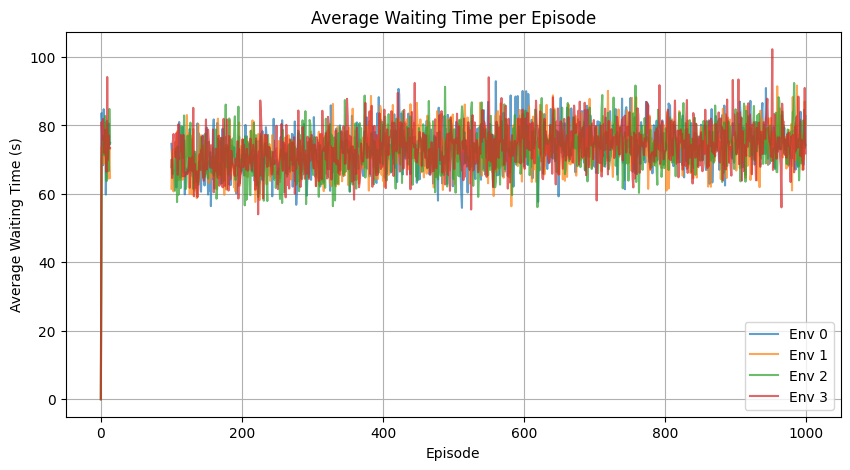

In [19]:
plt.figure(figsize=(10, 5))

for env in all["env"].unique():
    sub = all[all["env"] == env]
    plt.plot(
        sub["episode"],
        sub["avg_waiting_time"],
        label=f"Env {env}",
        alpha=0.7
    )

plt.xlabel("Episode")
plt.ylabel("Average Waiting Time (s)")
plt.title("Average Waiting Time per Episode")
plt.legend()
plt.grid(True)
plt.show()


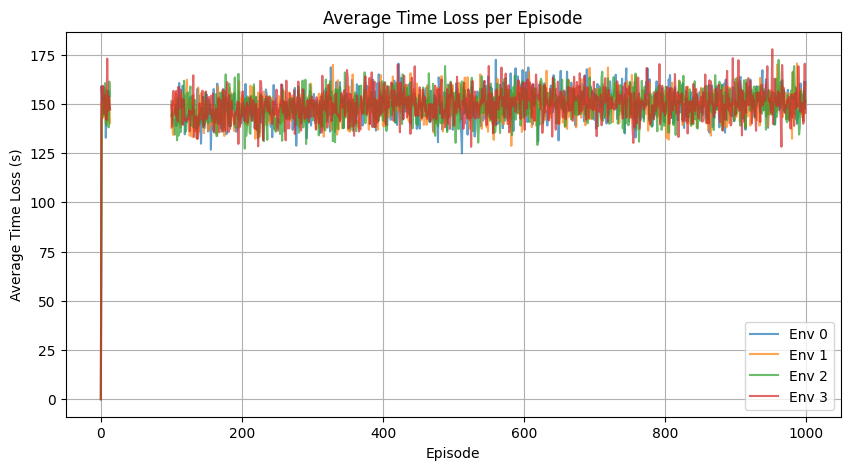

In [20]:
plt.figure(figsize=(10, 5))

for env in all["env"].unique():
    sub = all[all["env"] == env]
    plt.plot(
        sub["episode"],
        sub["avg_time_loss"],
        label=f"Env {env}",
        alpha=0.7
    )

plt.xlabel("Episode")
plt.ylabel("Average Time Loss (s)")
plt.title("Average Time Loss per Episode")
plt.legend()
plt.grid(True)
plt.show()


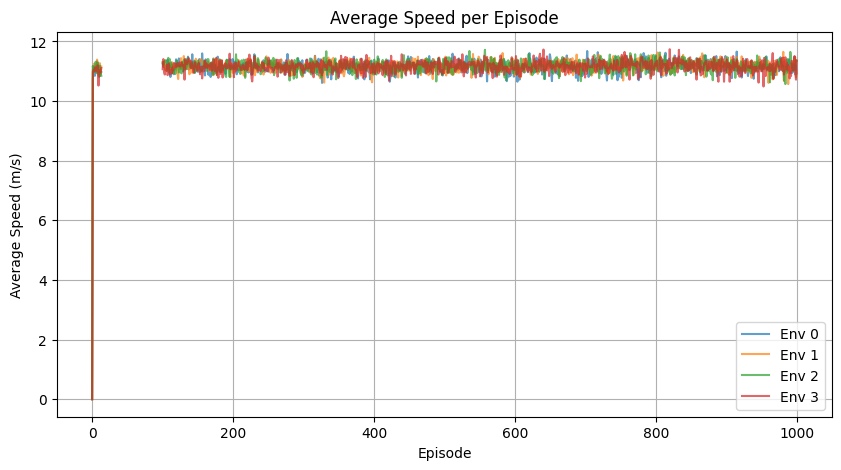

In [21]:
plt.figure(figsize=(10, 5))

for env in all["env"].unique():
    sub = all[all["env"] == env]
    plt.plot(
        sub["episode"],
        sub["avg_speed"],
        label=f"Env {env}",
        alpha=0.7
    )

plt.xlabel("Episode")
plt.ylabel("Average Speed (m/s)")
plt.title("Average Speed per Episode")
plt.legend()
plt.grid(True)
plt.show()


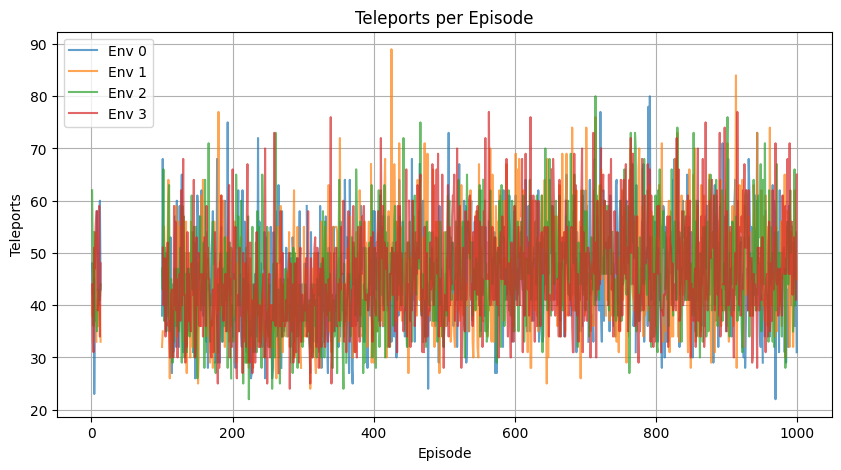

In [22]:
plt.figure(figsize=(10, 5))

for env in all["env"].unique():
    sub = all[all["env"] == env]
    plt.plot(
        sub["episode"],
        sub["teleports_total"],
        label=f"Env {env}",
        alpha=0.7
    )

plt.xlabel("Episode")
plt.ylabel("Teleports")
plt.title("Teleports per Episode")
plt.legend()
plt.grid(True)
plt.show()


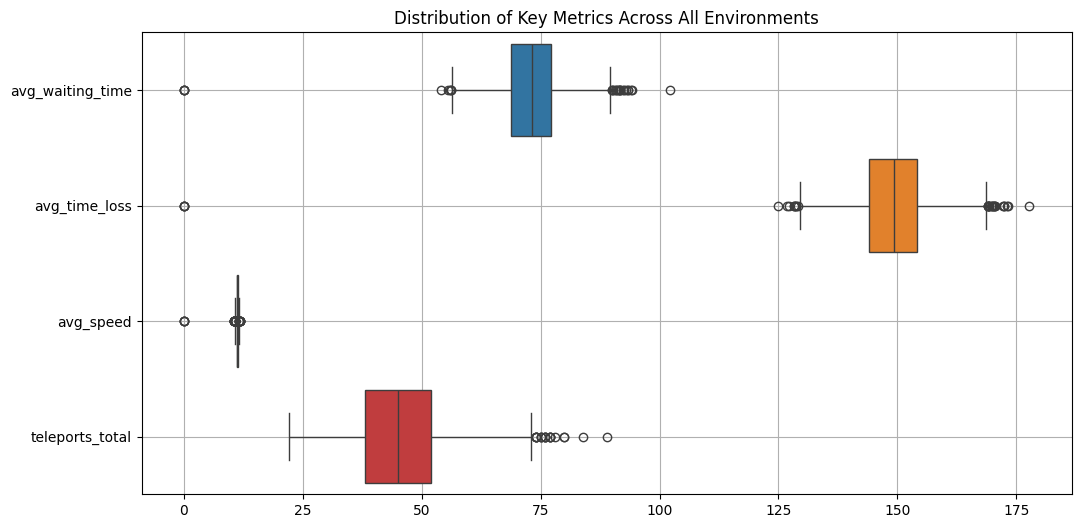

In [23]:
metrics = [
    "avg_waiting_time",
    "avg_time_loss",
    "avg_speed",
    "teleports_total"
]

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=all[metrics],
    orient="h"
)
plt.title("Distribution of Key Metrics Across All Environments")
plt.grid(True)
plt.show()


In [24]:
env_means = (
    all.groupby("env")[[
        "avg_waiting_time",
        "avg_time_loss",
        "avg_speed",
        "teleports_total"
    ]]
    .mean()
)

env_means


,avg_waiting_time,avg_time_loss,avg_speed,teleports_total
env,,,,
0,73.084562,149.081532,11.154617,45.329213
1,72.904037,148.894891,11.160197,45.784424
2,72.928446,148.847133,11.161575,45.770179
3,73.504814,149.472801,11.149847,45.759733


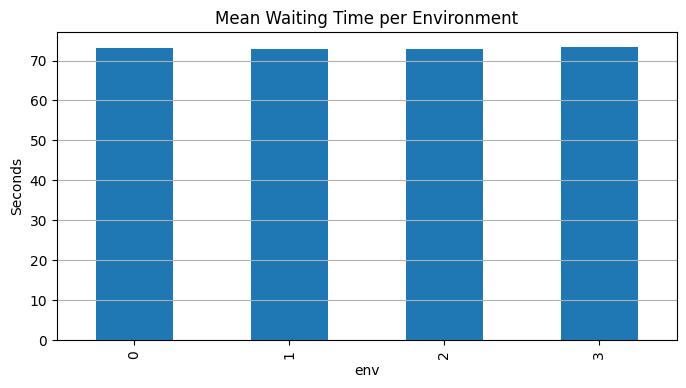

In [25]:
env_means["avg_waiting_time"].plot(
    kind="bar",
    figsize=(8, 4),
    title="Mean Waiting Time per Environment"
)

plt.ylabel("Seconds")
plt.grid(axis="y")
plt.show()


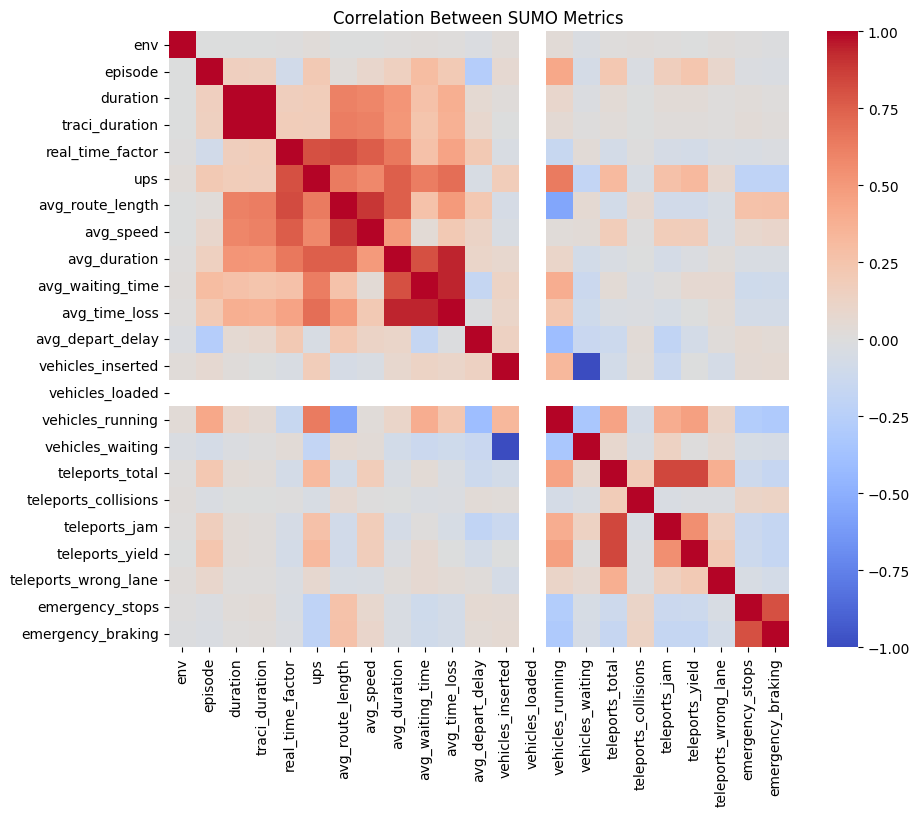

In [27]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    all.corr(numeric_only=True),
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Between SUMO Metrics")
plt.show()


In [29]:
rew = pd.read_csv('/home/yarl/Desktop/git/Urban/src/res/logs/DQN/model_parallel.csv')
rew

,0,1,2,3
0,-474170.302320,-375667.352910,-5.441140e+05,-520048.257836
1,-547848.566921,-392179.796459,-3.471160e+05,-417802.062360
2,-521024.665442,-332712.144215,-4.776093e+05,-329126.872490
3,-348303.461373,-481870.776334,-3.577571e+05,-451053.580885
4,-444674.560130,-480703.468293,-3.845388e+05,-617684.652276
...,...,...,...,...
895,-415123.157048,-505566.436474,-4.807512e+05,-623979.512150
896,-702704.012169,-410465.740836,-1.150522e+06,-532281.012299
897,-903299.152437,-668946.289791,-4.059080e+05,-506270.018038
898,-637251.100988,-820340.791110,-8.897247e+05,-904964.987184


In [30]:
rew['episode'] = rew.index + 1
rew.head()

,0,1,2,3,episode
0,-474170.302320,-375667.352910,-544113.987764,-520048.257836,1
1,-547848.566921,-392179.796459,-347115.985552,-417802.062360,2
2,-521024.665442,-332712.144215,-477609.332637,-329126.872490,3
3,-348303.461373,-481870.776334,-357757.081335,-451053.580885,4
4,-444674.560130,-480703.468293,-384538.763059,-617684.652276,5


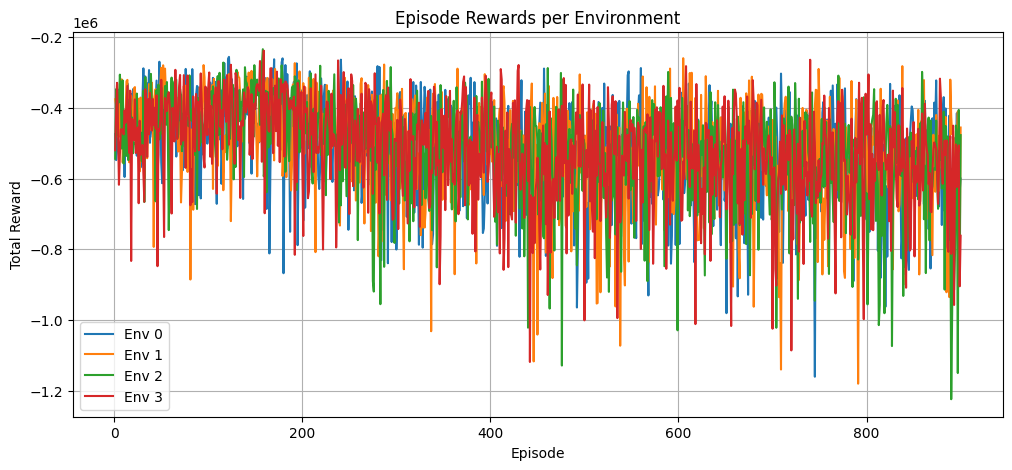

In [31]:
plt.figure(figsize=(12, 5))

for col in rew.columns[:-1]:  # exclude 'episode'
    plt.plot(
        rew["episode"],
        rew[col],
        label=f"Env {col}"
    )

plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Episode Rewards per Environment")
plt.legend()
plt.grid(True)
plt.show()


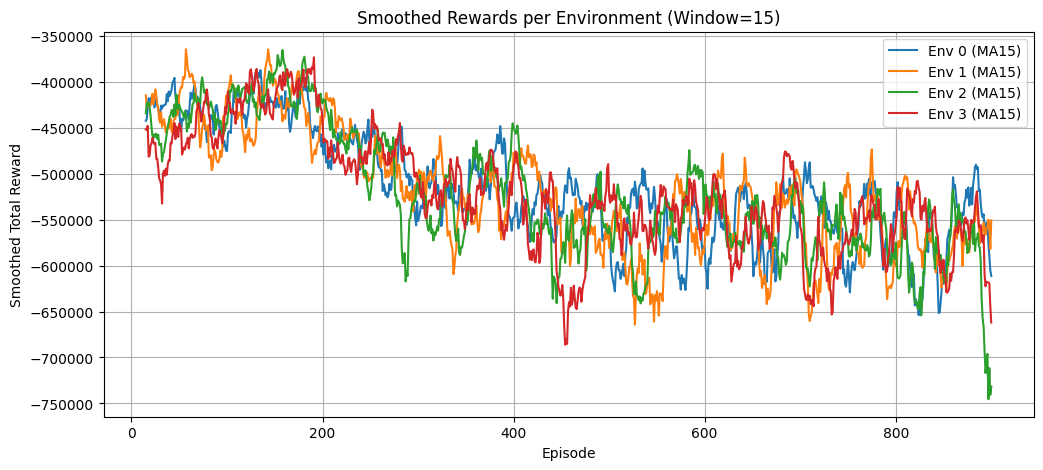

In [34]:
window = 15  # smooth over 50 episodes
plt.figure(figsize=(12, 5))

for col in rew.columns[:-1]:
    plt.plot(
        rew["episode"],
        rew[col].rolling(window=window).mean(),
        label=f"Env {col} (MA{window})"
    )

plt.xlabel("Episode")
plt.ylabel("Smoothed Total Reward")
plt.title(f"Smoothed Rewards per Environment (Window={window})")
plt.legend()
plt.grid(True)
plt.show()
